In [3]:
!pip install transformers jiwer datasets gradio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 36.0 MB/s eta 0:00:0000:0100:01


In [4]:
import os
import numpy as np
from tqdm.notebook import tqdm
import torch
import torch.nn as nn
from torch import optim
from torch.utils.data import Dataset, DataLoader
import torchaudio
import torchaudio.transforms as T
import torchaudio.functional as F
import matplotlib.pyplot as plt
from transformers import Wav2Vec2CTCTokenizer, get_cosine_schedule_with_warmup
from jiwer import wer

In [5]:
tokenizer = Wav2Vec2CTCTokenizer.from_pretrained("nguyenvulebinh/wav2vec2-base-vietnamese-250h")

tokenizer_config.json:   0%|          | 0.00/181 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/85.0 [00:00<?, ?B/s]

In [6]:
print(tokenizer.vocab)   

{'ẻ': 0, '6': 1, 'ụ': 2, 'í': 3, '3': 4, 'ỹ': 5, 'ý': 6, 'ẩ': 7, 'ở': 8, 'ề': 9, 'õ': 10, '7': 11, 'ê': 12, 'ứ': 13, 'ỏ': 14, 'v': 15, 'ỷ': 16, 'a': 17, 'l': 18, 'ự': 19, 'q': 20, 'ờ': 21, 'j': 22, 'ố': 23, 'à': 24, 'ỗ': 25, 'n': 26, 'é': 27, 'ủ': 28, 'у': 29, 'ô': 30, 'u': 31, 'y': 32, 'ằ': 33, '4': 34, 'w': 35, 'b': 36, 'ệ': 37, 'ễ': 38, 's': 39, 'ì': 40, 'ầ': 41, 'ỵ': 42, '8': 43, 'd': 44, 'ể': 45, 'r': 47, 'ũ': 48, 'c': 49, 'ạ': 50, '9': 51, 'ế': 52, 'ù': 53, 'ỡ': 54, '2': 55, 't': 56, 'i': 57, 'g': 58, '́': 59, 'ử': 60, '̀': 61, 'á': 62, '0': 63, 'ậ': 64, 'e': 65, 'ộ': 66, 'm': 67, 'ẳ': 68, 'ợ': 69, 'ĩ': 70, 'h': 71, 'â': 72, 'ú': 73, 'ọ': 74, 'ồ': 75, 'ặ': 76, 'f': 77, 'ữ': 78, 'ắ': 79, 'ỳ': 80, 'x': 81, 'ó': 82, 'ã': 83, 'ổ': 84, 'ị': 85, '̣': 86, 'z': 87, 'ả': 88, 'đ': 89, 'è': 90, 'ừ': 91, 'ò': 92, 'ẵ': 93, '1': 94, 'ơ': 95, 'k': 96, 'ẫ': 97, 'p': 98, 'ấ': 99, 'ẽ': 100, 'ỉ': 101, 'ớ': 102, 'ẹ': 103, 'ă': 104, 'o': 105, 'ư': 106, '5': 107, '|': 46, '<unk>': 108, '<pad>': 109}


In [7]:
# Làm giàu dữ liệu
from datasets import load_dataset

class LSVSCDataset(Dataset):
    def __init__(self, hf_dataset, tokenizer, sampling_rate=16000, is_train=True):
        self.dataset = hf_dataset
        self.tokenizer = tokenizer
        self.sampling_rate = sampling_rate
        self.is_train = is_train

        self.audio2mels = T.MelSpectrogram(
            sample_rate=sampling_rate,
            n_mels=80
        )
        self.amp2db = T.AmplitudeToDB(top_db=80.0)

        # --- THÊM SPECAUGMENT ---
        # Khởi tạo các phép biến đổi nếu đây là tập huấn luyện
        if self.is_train:
            # freq_mask_param: Số dải tần số (Mel bins) tối đa có thể bị che đi
            self.freq_masking = T.FrequencyMasking(freq_mask_param=15)
            # time_mask_param: Số khung thời gian tối đa có thể bị che đi
            self.time_masking = T.TimeMasking(time_mask_param=35)

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        # Lấy sample từ HuggingFace dataset
        item = self.dataset[idx]
        
        # Audio trong HF dataset thường nằm trong key 'audio' chứa 'array' và 'sampling_rate'
        audio_array = item["audio"]["array"]
        orig_sr = item["audio"]["sampling_rate"]
        
        # Chuyển array thành tensor
        audio = torch.tensor(audio_array, dtype=torch.float32).unsqueeze(0)

        # Resample nếu cần
        if orig_sr != self.sampling_rate:
            audio = F.resample(audio, orig_freq=orig_sr, new_freq=self.sampling_rate)

        ### Create Mel Spectrogram ###
        mel = self.audio2mels(audio)
        mel = self.amp2db(mel)

        # --- ÁP DỤNG SPECAUGMENT TRƯỚC KHI CHUẨN HOÁ DỮ LIỆU ---
        if self.is_train:
            mel = self.freq_masking(mel)
            mel = self.time_masking(mel)

        # Chuẩn hoá (Normalization)
        mel = (mel - mel.mean()) / (mel.std() + 1e-6)

        ### Tokenize Text ###
        transcript = item["transcription"].lower()
        tokenized_transcript = torch.tensor(self.tokenizer.encode(transcript))

        sample = {
            "input_values": mel[0].T,
            "labels": tokenized_transcript
        }
        return sample

In [8]:
# Làm giàu dữ liệu

### DATALOADERS ###
lsvsc_dataset = load_dataset("doof-ferb/LSVSC")

train_hf = lsvsc_dataset["train"]
test_hf = lsvsc_dataset["validation"] if "validation" in lsvsc_dataset else lsvsc_dataset["test"]

# Áp dụng Augmentation cho tập Train (is_train=True là mặc định)
trainset = LSVSCDataset(hf_dataset=train_hf, tokenizer=tokenizer, is_train=True)

# KHÔNG áp dụng Augmentation cho tập Test (bắt buộc is_train=False)
testset =  LSVSCDataset(hf_dataset=test_hf, tokenizer=tokenizer, is_train=False)

README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/18 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/18 [00:00<?, ?it/s]

data/train-00000-of-00018.parquet:   0%|          | 0.00/447M [00:00<?, ?B/s]

data/train-00001-of-00018.parquet:   0%|          | 0.00/522M [00:00<?, ?B/s]

...

data/test-00002-of-00003.parquet:   0%|          | 0.00/382M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/45458 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/5682 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/5683 [00:00<?, ? examples/s]

Loading dataset shards:   0%|          | 0/19 [00:00<?, ?it/s]

In [12]:
def collate_fn(batch):

    """
    This collate function is basically the heart of our implementation! It includes everything we need for training
    such as attention masks, sub_attention_masks, span_masks and our sampled negatives!
    """

    ### Sort Batch from Longest to Shortest (for future packed padding) ###
    batch = sorted(batch, key=lambda x: x["input_values"].shape[0], reverse=True)

    ### Grab Audios from our Batch Dictionary ###
    batch_mels = [sample["input_values"] for sample in batch]
    batch_transcripts = [sample["labels"] for sample in batch]

    ### Get Length of Audios ###
    seq_lens = torch.tensor([b.shape[0] for b in batch_mels], dtype=torch.long)

    ### Pad and Stack Spectrograms ###
    spectrograms = torch.nn.utils.rnn.pad_sequence(batch_mels, batch_first=True, padding_value=0)

    ### Convert to Shape Convolution Is Happy With (B x C x H x W) ###
    spectrograms = spectrograms.unsqueeze(1).transpose(-1,-2)

    ### Get Target Lengths ###
    target_lengths = torch.tensor([len(t) for t in batch_transcripts], dtype=torch.long)

    ### Pack Transcripts (CTC Loss Can Take Packed Targets) ###
    packed_transcripts = torch.cat(batch_transcripts)

    ### Create Batch ###
    batch = {"input_values": spectrograms,
             "seq_lens": seq_lens,
             "labels": packed_transcripts,
             "target_lengths": target_lengths}

    return batch

### Test Collate Function ###
loader = DataLoader(trainset, batch_size=5, collate_fn=collate_fn)
batch = next(iter(loader))

print("Input Values:", batch["input_values"].shape)
print("Seq Lens", batch["seq_lens"])
print("Labels:", batch["labels"].shape)
print("Target Lengths:", batch["target_lengths"])

### As required by the CTC loss, sum of the target lengths must equal the leng1276th of the flattened labels ###
if batch["target_lengths"].sum() == len(batch["labels"]):
    print("Sucess, Same Length")

Input Values: torch.Size([5, 1, 80, 679])
Seq Lens tensor([679, 431, 281, 281, 205])
Labels: torch.Size([349])
Target Lengths: tensor([125,  87,  43,  50,  44])
Sucess, Same Length


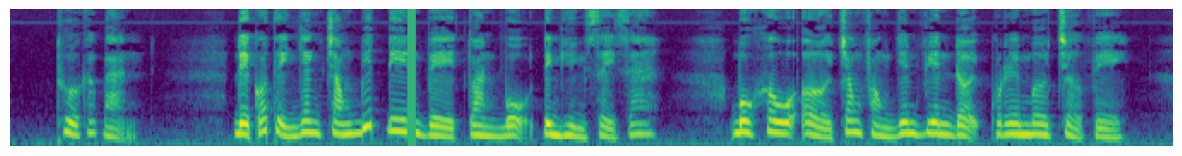

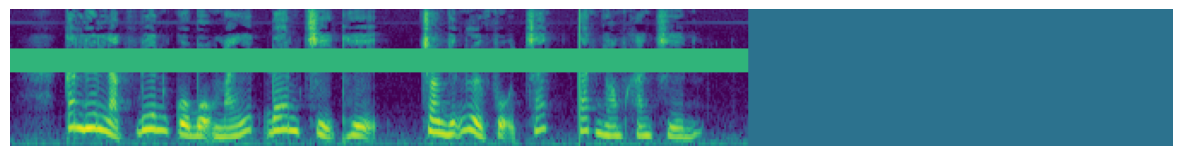

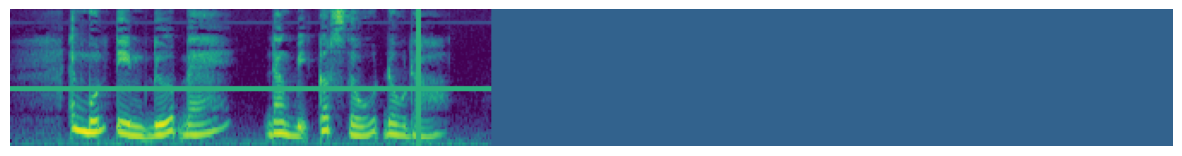

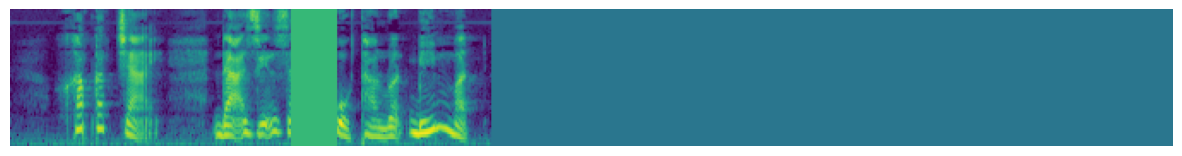

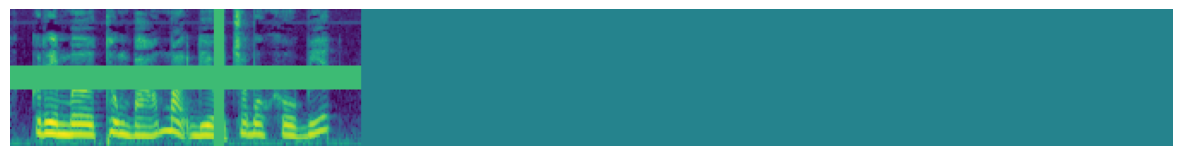

In [13]:
for samp in batch["input_values"]:

    ### Visualize (And Flip so Low frequencies are at the bottom) ###
    plt.figure(figsize=(15,5))
    plt.imshow(samp.squeeze())
    plt.axis("off")
    plt.gca().invert_yaxis()
    plt.show()

In [14]:
conv = nn.Conv2d(in_channels=1, out_channels=1, kernel_size=(3,3), stride=(1,2), padding=(1,0))

output = conv(batch["input_values"])

print("Output Shape:", output.shape)

Output Shape: torch.Size([5, 1, 80, 339])


In [15]:
padding = 0
kernel_size = 3
stride = 2

print("Input Seq Lens:", batch["seq_lens"])

output_seq_lens = torch.floor((batch["seq_lens"] + (2 * padding) - (kernel_size - 1) - 1) // stride + 1)

print("Output Seq Lens:", output_seq_lens)

Input Seq Lens: tensor([679, 431, 281, 281, 205])
Output Seq Lens: tensor([339, 215, 140, 140, 102])


In [16]:
### Create a Mask ###
mask = torch.nn.utils.rnn.pad_sequence([torch.ones(i) for i in output_seq_lens], padding_value=0, batch_first=True)

### Multiply out Output by the Mask (add in extra dimensions for channels and mel dimension) ###

print("Shortest Sample Without Mask")
print(output[-1], "\n")

output = output * mask.unsqueeze(1).unsqueeze(1)

print("Shortest Sample With Mask")
print(output[-1], "\n")

Shortest Sample Without Mask
tensor([[[ 0.0880,  0.0513,  0.0390,  ...,  0.1259,  0.1259,  0.1259],
         [-0.0987, -0.0648,  0.0267,  ...,  0.1259,  0.1259,  0.1259],
         [-0.3395, -0.1967, -0.1344,  ...,  0.1259,  0.1259,  0.1259],
         ...,
         [ 0.6322,  0.7920,  0.9918,  ...,  0.1259,  0.1259,  0.1259],
         [ 0.6325,  0.7486,  0.8251,  ...,  0.1259,  0.1259,  0.1259],
         [ 0.5008,  0.5930,  0.7595,  ...,  0.1259,  0.1259,  0.1259]]],
       grad_fn=<SelectBackward0>) 

Shortest Sample With Mask
tensor([[[ 0.0880,  0.0513,  0.0390,  ...,  0.0000,  0.0000,  0.0000],
         [-0.0987, -0.0648,  0.0267,  ...,  0.0000,  0.0000,  0.0000],
         [-0.3395, -0.1967, -0.1344,  ...,  0.0000,  0.0000,  0.0000],
         ...,
         [ 0.6322,  0.7920,  0.9918,  ...,  0.0000,  0.0000,  0.0000],
         [ 0.6325,  0.7486,  0.8251,  ...,  0.0000,  0.0000,  0.0000],
         [ 0.5008,  0.5930,  0.7595,  ...,  0.0000,  0.0000,  0.0000]]],
       grad_fn=<SelectBac

In [17]:
class MaskedConv2d(nn.Conv2d):

    """
    Our spectrograms are padded, so different spectrograms will have
    a different length. We need to make sure we dont include any padding information
    in our convolution, and update padding masks for the next convolution in the stack!

    Args:

    """

    def __init__(self,
                 in_channels,
                 out_channels,
                 kernel_size,
                 stride,
                 padding=0,
                 bias=True,
                 **kwargs):

        super(MaskedConv2d, self).__init__(in_channels=in_channels,
                                           out_channels=out_channels,
                                           kernel_size=kernel_size,
                                           stride=stride,
                                           padding=padding,
                                           bias=bias,
                                           **kwargs)

    def forward(self, x, seq_lens):

        """
        Updates convolution forward to zero out padding regions after convolution
        """

        batch_size, channels, height, width = x.shape

        ### Compute Output Seq Lengths of Each Sample After Convolution ###
        output_seq_lens = self._compute_output_seq_len(seq_lens)

        ### Pass Data Through Convolution ###
        conv_out = super().forward(x)

        ### Zero Out Any Values In The Padding Region (After Convolution) So they Dont Contribute ###
        mask = torch.zeros(batch_size, output_seq_lens.max(), device=x.device)
        for i, length in enumerate(output_seq_lens):
            mask[i, :length] = 1

        ### Unsqueeze mask to match image shape ###
        mask = mask.unsqueeze(1).unsqueeze(1)

        ### Apply Mask ###
        conv_out = conv_out * mask

        return conv_out, output_seq_lens

    def _compute_output_seq_len(self, seq_lens):

        """
        To perform masking AFTER the encoding 2D Convolutions, we need to
        compute what the shape of the output tensor is after each successive convolutions
        is applied.

        Convolution formula can be found in PyTorch Docs: https://pytorch.org/docs/stable/generated/torch.nn.Conv1d.html

        """

        return torch.floor((seq_lens + (2 * self.padding[1]) - (self.kernel_size[1] - 1) - 1) // self.stride[1]) + 1

In [18]:
class ConvolutionFeatureExtractor(nn.Module):

    def __init__(self,
                 in_channels=1,
                 out_channels=32):

        super(ConvolutionFeatureExtractor, self).__init__()

        self.in_channels = in_channels,
        self.out_channels = out_channels

        self.conv1 = MaskedConv2d(in_channels, out_channels, kernel_size=(11, 41), stride=(2,2), padding=(5,20), bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)

        self.conv2 = MaskedConv2d(out_channels, out_channels, kernel_size=(11, 21), stride=(2,1), padding=(5,10), bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        ### I just preset this, I know after I apply my two convolutions above with a kernel size of
        ### 11, that my output feature vectors will go from 80 down to 20! I could also dynamically
        ### compute this but its probably fine, I wont be changing the data after all!
        self.output_feature_dim = 20

        ### Compute Final Output Features ###
        self.conv_output_features = self.output_feature_dim * self.out_channels

    def forward(self, x, seq_lens):

        x, seq_lens = self.conv1(x, seq_lens)
        x = self.bn1(x)
        x = torch.nn.functional.hardtanh(x)

        x, seq_lens = self.conv2(x, seq_lens)
        x = self.bn2(x)
        x = torch.nn.functional.hardtanh(x)

        x = x.permute(0,3,1,2).flatten(2)

        return x, seq_lens

In [19]:
conv = ConvolutionFeatureExtractor()

conv_out, out_seq_lens = conv(batch["input_values"], batch["seq_lens"])

print("Convolution Output:", conv_out.shape)
print("Valid Seq Lens:", out_seq_lens)

### Pack the Convolution Output on Valid Timesteps ###
packed_conv_out = nn.utils.rnn.pack_padded_sequence(conv_out, out_seq_lens, batch_first=True)

print("Packed Output")
print(packed_conv_out)

Convolution Output: torch.Size([5, 340, 640])
Valid Seq Lens: tensor([340, 216, 141, 141, 103])
Packed Output
PackedSequence(data=tensor([[-0.0601, -0.3345, -0.1344,  ...,  1.0000,  0.4753,  1.0000],
        [-0.5025,  0.2548, -0.4089,  ...,  0.7853,  0.1432,  0.9534],
        [-0.4959, -1.0000, -1.0000,  ...,  0.4556,  0.2852,  1.0000],
        ...,
        [ 0.6259,  0.0650, -1.0000,  ...,  1.0000,  1.0000,  1.0000],
        [ 0.5511,  0.2552, -0.4461,  ...,  1.0000,  0.8390,  1.0000],
        [-0.2019,  0.3654, -0.0628,  ...,  0.3305,  0.7662,  0.8093]],
       grad_fn=<PackPaddedSequenceBackward0>), batch_sizes=tensor([5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,
        5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,
        5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,
        5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,
        5, 5, 5, 5, 5, 5, 5, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4

In [20]:
class RNNLayer(nn.Module):

    def __init__(self,
                 input_size,
                 hidden_size = 512):

        super(RNNLayer, self).__init__()

        self.hidden_dim = hidden_size
        self.input_size = input_size

        self.rnn = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            batch_first=True,
            bidirectional=True,
        )

        self.layernorm = nn.LayerNorm(2 * hidden_size)

    def forward(self, x, seq_lens):

        batch, seq_len, embed_dim = x.shape

        ### Pack Sequence (For efficient computation that ignores padding) ###
        packed_x = nn.utils.rnn.pack_padded_sequence(x, seq_lens, batch_first=True)

        ### Pass Packed Sequence through RNN ###
        out, _ = self.rnn(packed_x)

        ### Unpack (and repad) sequence ###
        x, _ = nn.utils.rnn.pad_packed_sequence(out, total_length=seq_len, batch_first=True)

        ### Normalize ###
        x = self.layernorm(x)

        return x


In [21]:
class DeepSpeech2(nn.Module):

    def __init__(self,
                 conv_in_channels=1,
                 conv_out_channels=32,
                 rnn_hidden_size=512,
                 rnn_depth=5):

        super(DeepSpeech2, self).__init__()

        self.feature_extractor = ConvolutionFeatureExtractor(
            conv_in_channels, conv_out_channels
        )

        self.output_hidden_features = self.feature_extractor.conv_output_features

        ### Stack Together RNN Layers ###
        ### First Layer has 640 inputs, everything after has 2 * 512 inputs ###
        self.rnns = nn.ModuleList(
            [
                RNNLayer(input_size=self.output_hidden_features if i==0 else 2 * rnn_hidden_size,
                         hidden_size=rnn_hidden_size)
                for i in range(rnn_depth)
            ]
        )

        ### Classification Head ###
        self.head = nn.Sequential(
            nn.Linear(2 * rnn_hidden_size, rnn_hidden_size),
            nn.Hardtanh(),
            nn.Linear(rnn_hidden_size, tokenizer.vocab_size)
        )

    def forward(self, x, seq_lens):

        ### Extract Features ###
        x, final_seq_lens = self.feature_extractor(x, seq_lens)

        ### Pass To RNN Layers ###
        for rnn in self.rnns:
            x = rnn(x, final_seq_lens)

        ### Classification Head ###
        x = self.head(x)

        return x, final_seq_lens

In [22]:
### TRAINING ARGUMENTS ###
BATCH_SIZE = 32
TRAINING_ITERATIONS = 10000
EVAL_ITERATIONS = 500
LEARNING_RATE = 5e-4
NUM_WORKERS = 4
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

trainloader = DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn, num_workers=NUM_WORKERS, pin_memory=True)
testloader = DataLoader(testset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn, num_workers=NUM_WORKERS, pin_memory=True)

### DEFINE MODEL ###
model = DeepSpeech2(conv_in_channels=1,
                    conv_out_channels=32,
                    rnn_hidden_size=512).to(DEVICE)

params = sum([p.numel() for p in model.parameters()])
print("Total Training Parameters:", params)

### OPTIMIZER/SCHEDULER ###
optimizer = optim.AdamW(params=model.parameters(), lr=LEARNING_RATE)
scheduler = get_cosine_schedule_with_warmup(optimizer,
                                            num_warmup_steps=500,
                                            num_training_steps=TRAINING_ITERATIONS)

Total Training Parameters: 23286606


In [23]:
### HOUSEKEEPING ###
best_val_loss = np.inf
train = True
completed_steps = 0
train_loss, validation_loss = [], []
pbar = tqdm(range(TRAINING_ITERATIONS))
scaler = torch.amp.GradScaler("cuda")

### TRAINING LOOP ###
while train:

    training_losses = []
    validation_losses = []

    for batch in trainloader:
        with torch.amp.autocast("cuda"):
            ### Pass Through Model and get input_lengths (post convolutions) and logits ###
            logits, input_lengths = model(x=batch["input_values"].to(DEVICE),
                                          seq_lens=batch["seq_lens"])
    
            ### CTC Expects Log Probabilities ###
            log_probs = nn.functional.log_softmax(logits, dim=-1)
    
            ### CTC Also Expects (T x B x C), we have (B x T x C) ###
            log_probs = log_probs.transpose(0,1)
    
            ### Compute CTC Loss ###
            loss = nn.functional.ctc_loss(
                log_probs=log_probs,
                targets=batch["labels"].to(DEVICE),
                input_lengths=input_lengths,
                target_lengths=batch["target_lengths"],
                blank=tokenizer.pad_token_id,
                reduction="mean",
            )

        ### Update Model ###
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad(set_to_none=True)
        scheduler.step()

        ### Store Loss ###
        training_losses.append(loss.item())

        ### Iterate Counter ###
        completed_steps += 1
        pbar.update(1)

        if completed_steps % EVAL_ITERATIONS == 0:

            print("Evaluating")

            model.eval()

            for batch in tqdm(testloader):

                ### Pass Through Model and get input_lengths (post convolutions) and logits ###
                with torch.no_grad():
                    logits, input_lengths = model(x=batch["input_values"].to(DEVICE),
                                                  seq_lens=batch["seq_lens"])

                ### CTC Expects Log Probabilities ###
                log_probs = nn.functional.log_softmax(logits, dim=-1)

                ### CTC Also Expects (T x B x C), we have (B x T x C) ###
                log_probs = log_probs.transpose(0,1)

                ### Compute CTC Loss ###
                loss = nn.functional.ctc_loss(
                    log_probs=log_probs,
                    targets=batch["labels"].to(DEVICE),
                    input_lengths=input_lengths,
                    target_lengths=batch["target_lengths"],
                    blank=tokenizer.pad_token_id,
                    reduction="mean",
                    zero_infinity=True
                )

                ### Store Loss ###
                validation_losses.append(loss.item())

            training_loss_mean = np.mean(training_losses)
            valid_loss_mean = np.mean(validation_losses)

            train_loss.append(training_loss_mean)
            validation_loss.append(valid_loss_mean)

            ### Save Model If Val Loss Decreases ###
            if valid_loss_mean < best_val_loss:
                print("---Saving Model---")
                torch.save(model.state_dict(), "best_weights.pt")
                best_val_loss = valid_loss_mean

            print("Training Loss:", training_loss_mean)
            print("Validation Loss:", valid_loss_mean)

            ### Reset Lists for Store ###
            training_losses = []
            validation_losses = []

            ### Set Model to Training Mode ###
            model.train()

        if completed_steps >= TRAINING_ITERATIONS:
            train = False
            print("Completed Training")
            break

  0%|          | 0/10000 [00:00<?, ?it/s]

Evaluating


  0%|          | 0/178 [00:00<?, ?it/s]

---Saving Model---
Training Loss: 3.11749068069458
Validation Loss: 1.68056223499641
Evaluating


  0%|          | 0/178 [00:00<?, ?it/s]

...

---Saving Model---
Training Loss: 0.4728272021571292
Validation Loss: 0.45203704060463423
Evaluating


  0%|          | 0/178 [00:00<?, ?it/s]

---Saving Model---
Training Loss: 0.46929157423973084
Validation Loss: 0.4511223817139529
Evaluating


  0%|          | 0/178 [00:00<?, ?it/s]

---Saving Model---
Training Loss: 0.45999173173364605
Validation Loss: 0.45011077176653935
Completed Training


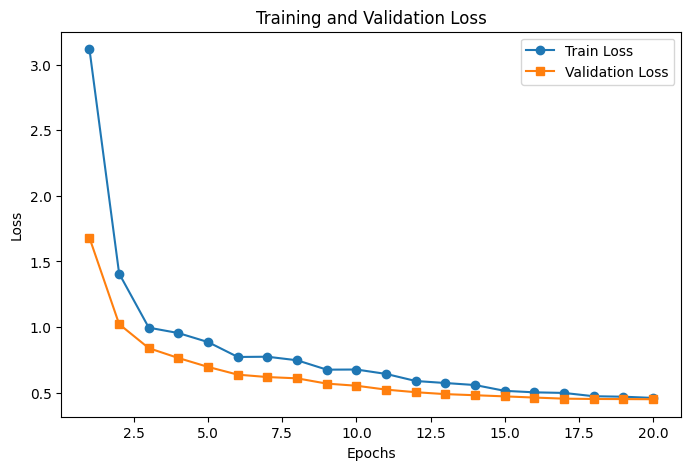

In [24]:
epochs = range(1, len(train_loss) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_loss, label="Train Loss", marker='o')
plt.plot(epochs, validation_loss, label="Validation Loss", marker='s')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

In [25]:
model = DeepSpeech2()
model.load_state_dict(torch.load("best_weights.pt", weights_only=True))

<All keys matched successfully>

In [26]:
def inference(audio_array, orig_sr, model, tokenizer, sampling_rate=16000, device="cpu"):
    ### Transforms ###
    audio2mels =  T.MelSpectrogram(
            sample_rate=sampling_rate,
            n_mels=80
        )
    amp2db = T.AmplitudeToDB(top_db=80.0)

    ### Convert Audio Array to Tensor ###
    audio = torch.tensor(audio_array, dtype=torch.float32).unsqueeze(0)
    
    # Resample nếu cần
    if orig_sr != sampling_rate:
        audio = torchaudio.functional.resample(audio, orig_freq=orig_sr, new_freq=sampling_rate)
        
    mel = audio2mels(audio)
    mel = amp2db(mel)
    mel = (mel - mel.mean()) / (mel.std() + 1e-6)

    ### Add in Batch Dimension ###
    mel = mel.unsqueeze(0)

    ### Compute src_len ###
    src_len = torch.tensor([mel.shape[-1]])

    ### Set Model Device ###
    model = model.to(device)

    ### Inference Model ###
    with torch.no_grad():
        pred_logits, _ = model(mel.to(device), src_len)

    ### Greedy Decode ###
    pred_tokens = pred_logits.squeeze().argmax(axis=-1).tolist()

    ### Prediction ###
    pred_transcript = tokenizer.decode(pred_tokens)

    return pred_transcript

### Grab a Random Sample from the Test Set ###
# Truy cập trực tiếp vào HuggingFace dataset
sample_item = testset.dataset[0] 
audio_array = sample_item["audio"]["array"]
orig_sr = sample_item["audio"]["sampling_rate"]
transcript = sample_item["transcription"].lower() # Đưa về in thường

### Predict Transcript ###
pred_transcript = inference(audio_array, orig_sr, model, tokenizer).lower()

print("Ground Truth:")
print(transcript, "\n")

print("Prediction:")
print(pred_transcript, "\n")

error = wer(transcript, pred_transcript)
print("Word Error Rate:")
print(error)

Ground Truth:
các trùm khối được cờ rê mơ triệu tập nhận mệnh lệnh sẵn sàng một vạn người sẽ phải di dời vào sáng ngày mai 

Prediction:
các chùmg khối được crê mơ triệu tập nhận mệnh lệnh sẵn sàng một vạn người sẽ phải di rời vào sáng này mai 

Word Error Rate:
0.2


In [27]:
errors = []
# Lặp qua các item trong test_hf dataset
for item in tqdm(testset.dataset):
    
    audio_array = item["audio"]["array"]
    orig_sr = item["audio"]["sampling_rate"]
    transcript = item["transcription"].lower() # In thường nhãn gốc

    ### Predict Transcript ###
    pred_transcript = inference(audio_array, orig_sr, model, tokenizer, device="cuda").lower()

    # Tính WER cho từng sample
    errors.append(wer(transcript, pred_transcript))

print("Overall Error")
print(np.mean(errors))

  0%|          | 0/5682 [00:00<?, ?it/s]

Overall Error
0.28189467119741063


In [ ]:
import gradio as gr
import torch
import torchaudio
import torchaudio.transforms as T

# 1. Set model to evaluation mode
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
model.eval() 

# 2. Define the Inference Wrapper for Gradio
def transcribe_audio(audio_path):
    if audio_path is None:
        return "Vui lòng cung cấp file âm thanh! (Please provide an audio file!)"

    # Audio Transforms
    sampling_rate = 16000
    audio2mels = T.MelSpectrogram(sample_rate=sampling_rate, n_mels=80)
    amp2db = T.AmplitudeToDB(top_db=80.0)

    # Load audio from Gradio's temporary file path
    audio, orig_sr = torchaudio.load(audio_path, normalize=True)

    # Convert stereo to mono if necessary (LibriSpeech/LSVSC expects 1 channel)
    if audio.shape[0] > 1:
        audio = torch.mean(audio, dim=0, keepdim=True)

    # Resample if the microphone/uploaded file has a different sample rate
    if orig_sr != sampling_rate:
        audio = torchaudio.functional.resample(audio, orig_freq=orig_sr, new_freq=sampling_rate)

    # Preprocessing
    mel = audio2mels(audio)
    mel = amp2db(mel)
    mel = (mel - mel.mean()) / (mel.std() + 1e-6)
    mel = mel.unsqueeze(0) # Add batch dimension
    src_len = torch.tensor([mel.shape[-1]])

    # Inference
    with torch.no_grad():
        # Use autocast if you trained with Mixed Precision (AMP)
        with torch.cuda.amp.autocast():
            pred_logits, _ = model(mel.to(DEVICE), src_len)

    # Decode
    pred_tokens = pred_logits.squeeze().argmax(axis=-1).tolist()
    pred_transcript = tokenizer.decode(pred_tokens)

    return pred_transcript.lower()

# 3. Build the Gradio Interface
demo = gr.Interface(
    fn=transcribe_audio,
    inputs=gr.Audio(
        sources=["microphone", "upload"], 
        type="filepath", 
        label="Record or Upload Vietnamese Audio"
    ),
    outputs=gr.Textbox(label="Predicted Transcript"),
    title="🎙️ Vietnamese Speech-to-Text (LSVSC)",
    description="Test your custom-trained DeepSpeech2 model! Click 'Record' and say a few words in Vietnamese.",
    theme="default"
)

# 4. Launch the App (share=True generates the public link)
demo.launch(share=True, debug=True)

* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://d88ab8add3500de36a.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


/tmp/ipykernel_57/1683897497.py:41: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/tmp/ipykernel_57/1683897497.py:41: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/tmp/ipykernel_57/1683897497.py:41: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
